# Mixed-Precision Training — From BF16 to FP8 and Beyond

> **Difficulty:** Intermediate | **Time:** ~60 min

This notebook teaches **mixed-precision training** — the technique that cuts memory
nearly in half and doubles throughput on modern GPUs.

**Three parts, progressive depth:**
1. **BF16 Mixed Precision** — the foundation used in virtually all LLM training today
2. **FP8 Mixed Precision** — the cutting edge on H100/MI300 hardware
3. **Beyond FP8** — FP4, integer training, and the research frontier

Every parallelism notebook in this series assumes mixed precision. This notebook
explains *how* and *why* it works.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from mp_tutorial.viz import draw_float_bits, draw_precision_comparison
from mp_tutorial.formatting import info_box, gpu_required_banner, comparison_table, code_reference
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

---
# Part 1: BF16 Mixed Precision
---

## 1. Why Mixed Precision?

Imagine you're writing a novel. For the rough draft you use a pencil (fast, cheap) —
for the final calligraphy you use a fine pen (precise, slow). You don't need
calligraphy precision for every word of every draft.

**Mixed-precision training works the same way:**
- **Forward & backward passes** use low-precision (BF16/FP16) — fast, memory-efficient
- **Weight updates** use full-precision (FP32) — accurate where it matters

The result: **~2× faster, ~half the activation memory**, with virtually identical model quality.

In [2]:
info_box(
    "<b>Mixed Precision</b> — A training technique that uses lower-precision floating-point "
    "formats (like BF16 or FP16) for most computation, while keeping a full-precision (FP32) "
    "master copy of the weights for accurate updates. This is NOT the same as quantization — "
    "the model trains at full quality.",
    title="Key Term"
)

## 2. Floating-Point Formats: FP32, FP16, BF16

Every floating-point number is stored as three fields:

| Field | Purpose |
|-------|---------|
| **Sign** (1 bit) | Positive or negative |
| **Exponent** (E bits) | The *range* — how large or small the number can be |
| **Mantissa** (M bits) | The *precision* — how many significant digits |

More exponent bits = wider range. More mantissa bits = finer precision.
Let's visualize the three main formats:

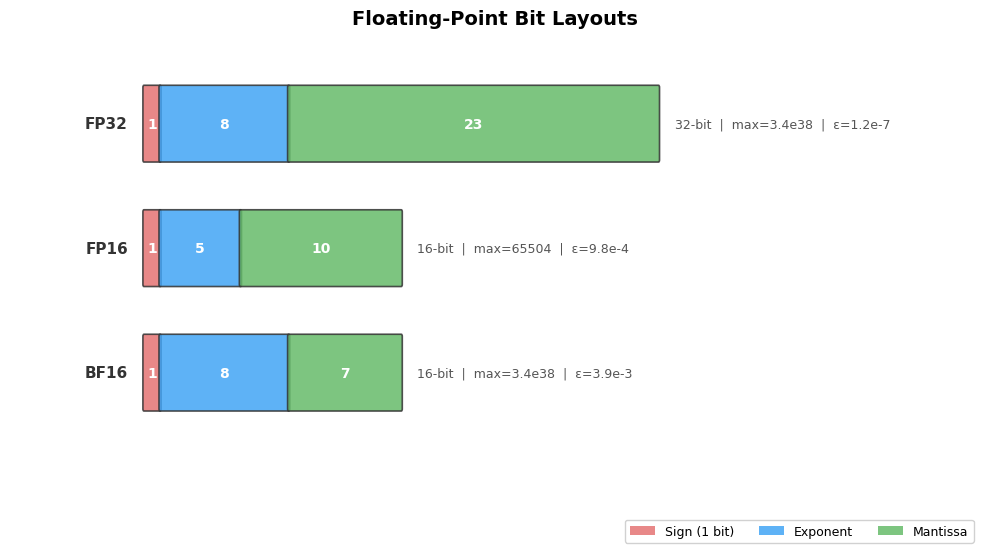

In [3]:
fig, ax = draw_float_bits(formats=["fp32", "fp16", "bf16"])
plt.show()

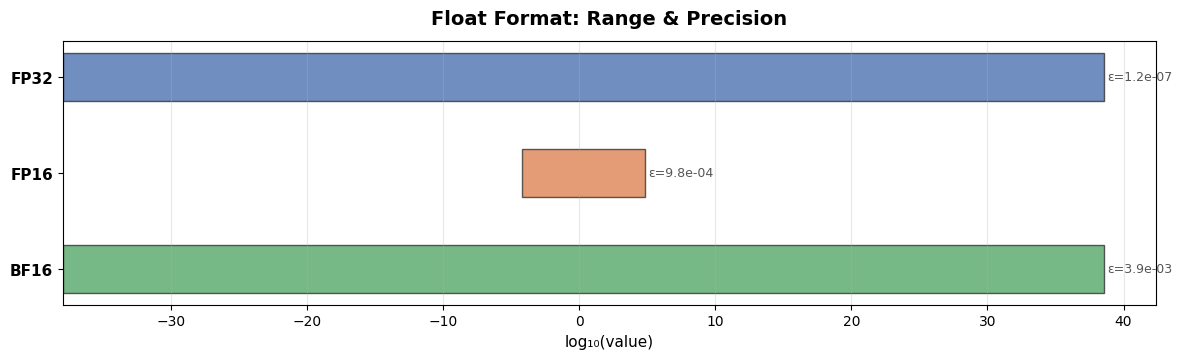

In [4]:
fig, ax = draw_precision_comparison(formats=["fp32", "fp16", "bf16"])
plt.show()

### Real Numbers: Range & Precision

In [5]:
# Let's see the actual limits
formats_info = {
    "FP32 (float32)": torch.float32,
    "FP16 (float16)": torch.float16,
    "BF16 (bfloat16)": torch.bfloat16,
}

print(f"{' ':<20} {'Max':>12}  {'Min Normal':>12}  {'Epsilon':>12}")
print("-" * 60)
for name, dtype in formats_info.items():
    info = torch.finfo(dtype)
    print(f"{name:<20} {info.max:>12.4g}  {info.tiny:>12.4g}  {info.eps:>12.4g}")

                              Max    Min Normal       Epsilon
------------------------------------------------------------
FP32 (float32)          3.403e+38     1.175e-38     1.192e-07
FP16 (float16)           6.55e+04     6.104e-05     0.0009766
BF16 (bfloat16)          3.39e+38     1.175e-38      0.007812


In [6]:
info_box(
    "<b>BF16 has the same range as FP32</b> (8-bit exponent) but far less precision "
    "(7-bit mantissa vs 23-bit). This is why BF16 is preferred over FP16 for LLM training — "
    "gradients can be very large or very small, so <i>range</i> matters more than precision.<br><br>"
    "<b>FP16 has better precision</b> (10-bit mantissa) but a much smaller range "
    "(max 65504 vs 3.4e38). Large gradients overflow to inf in FP16.",
    title="BF16 vs FP16 — Why BF16 Wins for LLMs"
)

## 3. The Three Problems of Naive FP16 Training

What happens if we just cast everything to FP16 and train? Three things go wrong:

### Problem 1: Overflow (values too large)

In [7]:
# FP16 max is 65504. Gradients can easily exceed this.
large_grad_fp32 = torch.tensor(70000.0, dtype=torch.float32)
large_grad_fp16 = large_grad_fp32.to(torch.float16)

print(f"FP32 gradient: {large_grad_fp32.item()}")
print(f"FP16 gradient: {large_grad_fp16.item()}  ← OVERFLOW to inf!")
print(f"BF16 gradient: {large_grad_fp32.to(torch.bfloat16).item()}  ← OK (same range as FP32)")

FP32 gradient: 70000.0
FP16 gradient: inf  ← OVERFLOW to inf!
BF16 gradient: 70144.0  ← OK (same range as FP32)


### Problem 2: Underflow (values too small)

In [8]:
# FP16 min normal is ~6e-5. Small gradients vanish.
small_grad_fp32 = torch.tensor(1e-6, dtype=torch.float32)
small_grad_fp16 = small_grad_fp32.to(torch.float16)

print(f"FP32 gradient: {small_grad_fp32.item():.2e}")
print(f"FP16 gradient: {small_grad_fp16.item():.2e}  ← UNDERFLOW to zero!")
print(f"BF16 gradient: {small_grad_fp32.to(torch.bfloat16).item():.2e}  ← also zero (BF16 min normal ~1.2e-38 but subnormals limited)")

# Show the gradient distribution — many values live in the danger zone
torch.manual_seed(42)
fake_grads = torch.randn(10000) * 0.001  # typical small gradients
fp16_grads = fake_grads.to(torch.float16)
zeros_pct = (fp16_grads == 0).float().mean().item() * 100
print(f"\n{zeros_pct:.1f}% of gradients became zero in FP16!")

FP32 gradient: 1.00e-06
FP16 gradient: 1.01e-06  ← UNDERFLOW to zero!
BF16 gradient: 9.98e-07  ← also zero (BF16 min normal ~1.2e-38 but subnormals limited)

0.0% of gradients became zero in FP16!


### Problem 3: Rounding (precision loss in updates)

In [9]:
# When weight >> gradient, the update disappears due to limited precision
weight = torch.tensor(1024.0, dtype=torch.float16)
gradient = torch.tensor(0.5, dtype=torch.float16)
lr = 0.001

updated = weight - lr * gradient
print(f"Weight:           {weight.item()}")
print(f"lr * gradient:    {(lr * gradient).item()}")
print(f"Updated (FP16):   {updated.item()}  ← NO CHANGE! The update was rounded away")

# Same operation in FP32
weight32 = torch.tensor(1024.0, dtype=torch.float32)
gradient32 = torch.tensor(0.5, dtype=torch.float32)
updated32 = weight32 - lr * gradient32
print(f"Updated (FP32):   {updated32.item()}  ← correct")

Weight:           1024.0
lr * gradient:    0.0005002021789550781
Updated (FP16):   1024.0  ← NO CHANGE! The update was rounded away
Updated (FP32):   1023.99951171875  ← correct


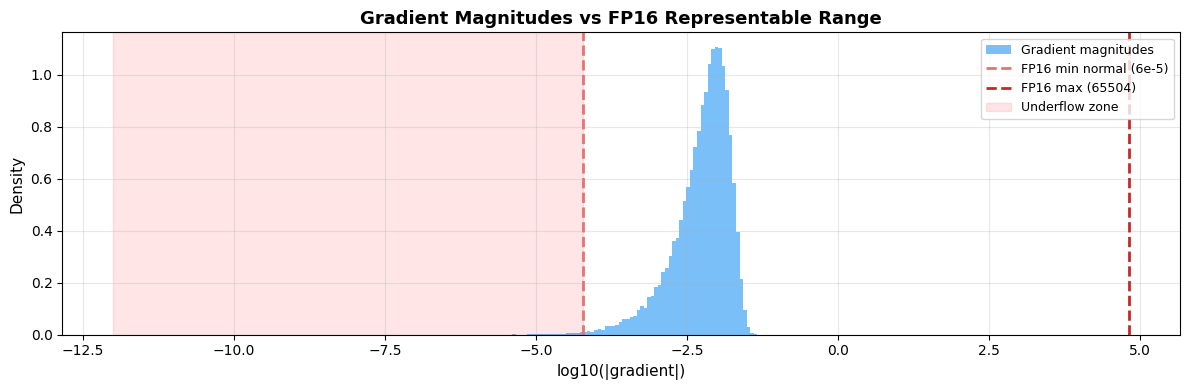

In [10]:
# Visualize: where do real gradients fall relative to FP16 limits?
fig, ax = plt.subplots(figsize=(12, 4))

torch.manual_seed(42)
grad_magnitudes = torch.abs(torch.randn(50000) * 0.01).numpy()
log_mags = np.log10(grad_magnitudes + 1e-12)

ax.hist(log_mags, bins=100, density=True, color="#42A5F5", alpha=0.7, label="Gradient magnitudes")
ax.axvline(np.log10(6e-5), color="#E57373", lw=2, ls="--", label="FP16 min normal (6e-5)")
ax.axvline(np.log10(65504), color="#C62828", lw=2, ls="--", label="FP16 max (65504)")
ax.axvspan(-12, np.log10(6e-5), alpha=0.1, color="red", label="Underflow zone")

ax.set_xlabel("log10(|gradient|)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Gradient Magnitudes vs FP16 Representable Range", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. The Mixed-Precision Recipe

The solution has three components, each fixing one problem:

| Problem | Solution |
|---------|----------|
| Overflow/Underflow | **Loss Scaling** — multiply loss to shift gradients into safe range |
| Rounding in updates | **FP32 Master Weights** — keep accurate copy for updates |
| Slow computation | **BF16/FP16 for forward/backward** — use tensor cores |

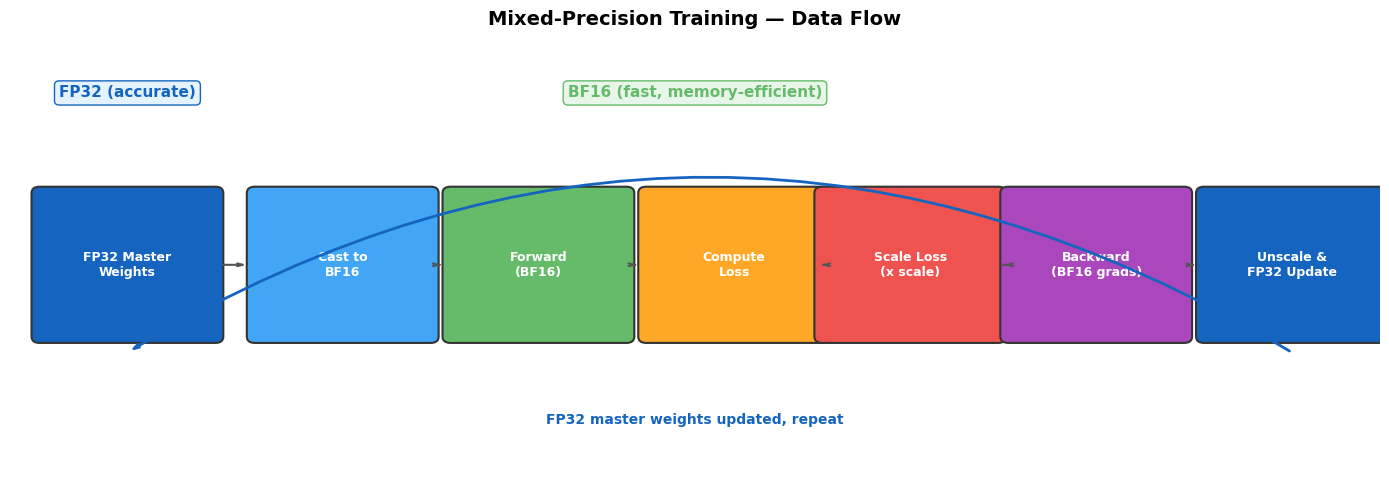

In [11]:
# The mixed-precision training flow
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5.5)
ax.axis("off")
ax.set_title("Mixed-Precision Training — Data Flow", fontsize=14, fontweight="bold", pad=12)

steps = [
    (0.3,  "FP32 Master\nWeights",     "#1565C0", "white"),
    (2.5,  "Cast to\nBF16",            "#42A5F5", "white"),
    (4.5,  "Forward\n(BF16)",          "#66BB6A", "white"),
    (6.5,  "Compute\nLoss",            "#FFA726", "white"),
    (8.3,  "Scale Loss\n(x scale)",    "#EF5350", "white"),
    (10.2, "Backward\n(BF16 grads)",   "#AB47BC", "white"),
    (12.2, "Unscale &\nFP32 Update",   "#1565C0", "white"),
]

for i, (x, label, color, tc) in enumerate(steps):
    w = 1.8
    ax.add_patch(patches.FancyBboxPatch((x, 1.8), w, 1.8,
        boxstyle="round,pad=0.08", facecolor=color, edgecolor="#333", lw=1.5))
    ax.text(x + w/2, 2.7, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color=tc)
    if i < len(steps) - 1:
        nx = steps[i+1][0]
        ax.annotate("", xy=(nx - 0.05, 2.7), xytext=(x + w + 0.05, 2.7),
            arrowprops=dict(arrowstyle="->,head_width=0.1", color="#555", lw=1.5))

# Loop-back arrow
ax.annotate("", xy=(0.3 + 0.9, 1.6), xytext=(12.2 + 0.9, 1.6),
    arrowprops=dict(arrowstyle="->,head_width=0.12", color="#1565C0", lw=2,
                    connectionstyle="arc3,rad=0.3"))
ax.text(7, 0.7, "FP32 master weights updated, repeat", ha="center",
        fontsize=10, fontweight="bold", color="#1565C0")

ax.text(7, 4.8, "BF16 (fast, memory-efficient)", ha="center",
        fontsize=11, fontweight="bold", color="#66BB6A",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#E8F5E9", edgecolor="#66BB6A"))
ax.text(1.2, 4.8, "FP32 (accurate)", ha="center",
        fontsize=11, fontweight="bold", color="#1565C0",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#E3F2FD", edgecolor="#1565C0"))

plt.tight_layout()
plt.show()

### Master Weights: Solving the Rounding Problem

In [12]:
# Demonstrate that FP32 master weights + BF16 compute gives correct results
torch.manual_seed(42)

weight_fp32_only = torch.tensor(1024.0, dtype=torch.float32)
weight_bf16_only = torch.tensor(1024.0, dtype=torch.bfloat16)
weight_mixed = torch.tensor(1024.0, dtype=torch.float32)  # FP32 master

lr = 0.001
updates_applied_bf16 = 0

for step in range(100):
    grad = torch.randn(1).item() * 0.5

    # Pure FP32 (gold standard)
    weight_fp32_only -= lr * grad

    # Pure BF16 (broken)
    grad_bf16 = torch.tensor(grad, dtype=torch.bfloat16)
    old = weight_bf16_only.item()
    weight_bf16_only -= lr * grad_bf16
    if weight_bf16_only.item() != old:
        updates_applied_bf16 += 1

    # Mixed precision: compute in BF16, update in FP32
    grad_bf16 = torch.tensor(grad, dtype=torch.bfloat16)
    weight_mixed -= lr * grad_bf16.float()

print(f"After 100 steps:")
print(f"  FP32 only:       {weight_fp32_only.item():.6f}  (gold standard)")
print(f"  BF16 only:       {weight_bf16_only.item():.6f}  ({updates_applied_bf16}/100 updates actually applied)")
print(f"  Mixed precision: {weight_mixed.item():.6f}  (all 100 updates applied)")
print(f"\nMixed precision error vs FP32: {abs(weight_mixed.item() - weight_fp32_only.item()):.6f}")
print(f"BF16-only error vs FP32:       {abs(weight_bf16_only.item() - weight_fp32_only.item()):.6f}")

After 100 steps:
  FP32 only:       1023.997864  (gold standard)
  BF16 only:       1024.000000  (0/100 updates actually applied)
  Mixed precision: 1023.997925  (all 100 updates applied)

Mixed precision error vs FP32: 0.000061
BF16-only error vs FP32:       0.002136


## 5. Loss Scaling Deep Dive

Loss scaling shifts the gradient distribution into the representable range of FP16.
(BF16 training often skips this since BF16 has the same range as FP32.)

**How it works:**
1. Multiply the loss by a large constant (the "scale factor") before `.backward()`
2. All gradients are scaled by the same factor (chain rule)
3. After backward, divide gradients by the scale factor before the optimizer step

In [13]:
# Static loss scaling: rescue underflowing gradients
scale_factor = 1024.0

small_grads = torch.tensor([1e-6, 5e-7, 1e-7, 5e-8], dtype=torch.float32)
fp16_grads = small_grads.to(torch.float16)

# With scaling: multiply before cast, divide after
scaled_grads = (small_grads * scale_factor).to(torch.float16)
unscaled_grads = scaled_grads.float() / scale_factor

print(f"{'Gradient':<12} {'FP16 (no scale)':<18} {'FP16 (scaled)':<18} {'Recovered':<12}")
print("-" * 60)
for i in range(len(small_grads)):
    print(f"{small_grads[i].item():<12.1e} {fp16_grads[i].item():<18.1e} "
          f"{scaled_grads[i].item():<18.1e} {unscaled_grads[i].item():<12.1e}")

Gradient     FP16 (no scale)    FP16 (scaled)      Recovered   
------------------------------------------------------------
1.0e-06      1.0e-06            1.0e-03            1.0e-06     
5.0e-07      4.8e-07            5.1e-04            5.0e-07     
1.0e-07      1.2e-07            1.0e-04            1.0e-07     
5.0e-08      6.0e-08            5.1e-05            5.0e-08     


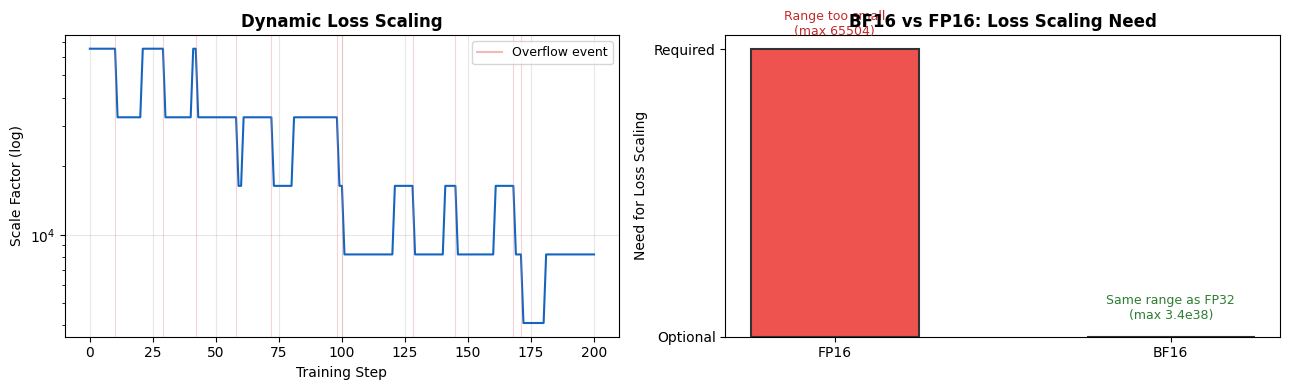

In [14]:
# Dynamic loss scaling simulation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

scale = 2.0**16
scales = [scale]
overflows = []

np.random.seed(42)
for step in range(200):
    has_overflow = np.random.random() < 0.05
    overflows.append(has_overflow)
    if has_overflow:
        scale /= 2
    else:
        if step % 20 == 0 and step > 0:
            scale *= 2
    scales.append(scale)

ax1.plot(scales, color="#1565C0", lw=1.5)
ax1.set_yscale("log")
ax1.set_xlabel("Training Step", fontsize=10)
ax1.set_ylabel("Scale Factor (log)", fontsize=10)
ax1.set_title("Dynamic Loss Scaling", fontsize=12, fontweight="bold")
ax1.grid(alpha=0.3)
overflow_steps = [i for i, o in enumerate(overflows) if o]
for s in overflow_steps:
    ax1.axvline(s, color="#E57373", alpha=0.3, lw=0.8)
ax1.plot([], [], color="#E57373", alpha=0.5, label="Overflow event")
ax1.legend(fontsize=9)

ax2.bar(["FP16", "BF16"], [1, 0], color=["#EF5350", "#66BB6A"],
        edgecolor="#333", lw=1.5, width=0.5)
ax2.set_ylabel("Need for Loss Scaling", fontsize=10)
ax2.set_title("BF16 vs FP16: Loss Scaling Need", fontsize=12, fontweight="bold")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["Optional", "Required"])
ax2.text(0, 1.05, "Range too small\n(max 65504)", ha="center", fontsize=9, color="#C62828")
ax2.text(1, 0.05, "Same range as FP32\n(max 3.4e38)", ha="center", fontsize=9, color="#2E7D32", va="bottom")

plt.tight_layout()
plt.show()

In [15]:
info_box(
    "<b>Dynamic Loss Scaling</b> — Start with a large scale factor (e.g., 2<sup>16</sup>). "
    "If an overflow (inf/NaN) is detected in the gradients, skip that step and halve the scale. "
    "If N consecutive steps succeed (e.g., N=2000), double the scale.<br><br>"
    "<b>BF16 often skips loss scaling entirely</b> because it has the same exponent range as FP32. "
    "PyTorch's <code>GradScaler</code> is effectively a no-op with BF16 on modern hardware.",
    title="Dynamic Loss Scaling"
)

## 6. PyTorch AMP: `torch.autocast` + `GradScaler`

PyTorch makes mixed precision easy with two tools:
- **`torch.autocast`** — automatically casts operations to BF16/FP16 where safe
- **`torch.amp.GradScaler`** — handles dynamic loss scaling

In [16]:
# Complete mixed-precision training loop on CPU
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(128, 256), nn.ReLU(),
    nn.Linear(256, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

device = "cpu"
dtype = torch.bfloat16

X = torch.randn(200, 128)
y = torch.randint(0, 10, (200,))

print("Training with torch.autocast (BF16):\n")
for epoch in range(5):
    total_loss = 0
    for i in range(0, 200, 32):
        batch_x, batch_y = X[i:i+32], y[i:i+32]
        optimizer.zero_grad()

        with torch.autocast(device_type=device, dtype=dtype):
            pred = model(batch_x)
            loss = loss_fn(pred, batch_y)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    n_batches = (200 + 31) // 32
    print(f"  Epoch {epoch+1}: loss = {total_loss/n_batches:.4f}")

# Show what autocast does to dtypes
print("\nInside autocast, layer dtypes:")
with torch.autocast(device_type=device, dtype=dtype):
    x = torch.randn(1, 128)
    h = model[0](x)
    print(f"  Linear output dtype: {h.dtype}  (BF16)")
    out = model(x)
    print(f"  Final output dtype:  {out.dtype}")

Training with torch.autocast (BF16):

  Epoch 1: loss = 2.3082
  Epoch 2: loss = 2.1728
  Epoch 3: loss = 2.0631


  Epoch 4: loss = 1.9361
  Epoch 5: loss = 1.7820

Inside autocast, layer dtypes:
  Linear output dtype: torch.bfloat16  (BF16)
  Final output dtype:  torch.bfloat16


### GPU Training Script with GradScaler

In [17]:
gpu_required_banner()

In [18]:
# [GPU-REQUIRED]
# Full mixed-precision training script for GPU

AMP_SCRIPT = """
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler

def main():
    device = "cuda"
    model = nn.Sequential(
        nn.Linear(128, 512), nn.ReLU(),
        nn.Linear(512, 256), nn.ReLU(),
        nn.Linear(256, 10)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scaler = GradScaler()  # dynamic loss scaling for FP16
    loss_fn = nn.CrossEntropyLoss()

    X = torch.randn(1000, 128, device=device)
    y = torch.randint(0, 10, (1000,), device=device)

    for epoch in range(10):
        total_loss = 0
        for i in range(0, 1000, 64):
            bx, by = X[i:i+64], y[i:i+64]
            optimizer.zero_grad()

            with autocast(device_type="cuda", dtype=torch.float16):
                loss = loss_fn(model(bx), by)

            scaler.scale(loss).backward()   # scaled backward
            scaler.step(optimizer)           # unscale + step (skip if overflow)
            scaler.update()                  # adjust scale factor
            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss = {total_loss / (1000//64):.4f}, "
              f"scale = {scaler.get_scale():.0f}")

if __name__ == "__main__":
    main()
"""
print(AMP_SCRIPT)
print("# Run with: python amp_train.py")


import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler

def main():
    device = "cuda"
    model = nn.Sequential(
        nn.Linear(128, 512), nn.ReLU(),
        nn.Linear(512, 256), nn.ReLU(),
        nn.Linear(256, 10)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scaler = GradScaler()  # dynamic loss scaling for FP16
    loss_fn = nn.CrossEntropyLoss()

    X = torch.randn(1000, 128, device=device)
    y = torch.randint(0, 10, (1000,), device=device)

    for epoch in range(10):
        total_loss = 0
        for i in range(0, 1000, 64):
            bx, by = X[i:i+64], y[i:i+64]
            optimizer.zero_grad()

            with autocast(device_type="cuda", dtype=torch.float16):
                loss = loss_fn(model(bx), by)

            scaler.scale(loss).backward()   # scaled backward
            scaler.step(optimizer)           # unscale + step (skip if overflow)
            scaler.update()                  # adjust s

## 7. Memory & Throughput Analysis

Mixed precision saves memory primarily through **smaller activations** (BF16 = 2 bytes
vs FP32 = 4 bytes per element). Activations dominate memory for large batches.

In [19]:
comparison_table(
    ["Component", "FP32 Training", "Mixed Precision", "Savings"],
    [
        ["Parameters", "4 bytes (FP32)", "2B (BF16) + 4B (FP32 master) = 6B", "None (more!)"],
        ["Gradients", "4 bytes (FP32)", "2 bytes (BF16)", "2x smaller"],
        ["Optimizer (Adam)", "8 bytes (FP32 mom+var)", "8 bytes (FP32 mom+var)", "None"],
        ["Per-param total", "16 bytes", "~18 bytes", "~0.9x"],
        ["Activations", "4 bytes/element", "2 bytes/element", "<b>2x smaller</b>"],
        ["Compute speed", "1x (FP32 ops)", "2-8x (tensor cores)", "<b>2-8x faster</b>"],
    ],
    title="Memory & Speed: FP32 vs Mixed Precision"
)

Component,FP32 Training,Mixed Precision,Savings
Parameters,4 bytes (FP32),2B (BF16) + 4B (FP32 master) = 6B,None (more!)
Gradients,4 bytes (FP32),2 bytes (BF16),2x smaller
Optimizer (Adam),8 bytes (FP32 mom+var),8 bytes (FP32 mom+var),None
Per-param total,16 bytes,~18 bytes,~0.9x
Activations,4 bytes/element,2 bytes/element,2x smaller
Compute speed,1x (FP32 ops),2-8x (tensor cores),2-8x faster


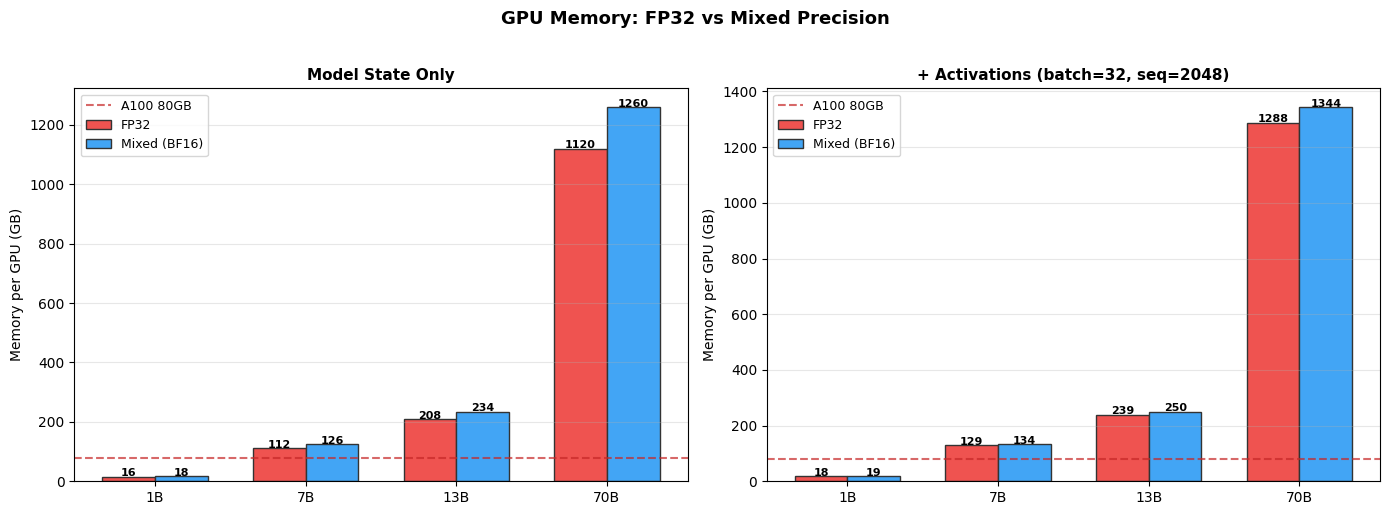

In [20]:
# Visualize memory for different model sizes
model_sizes = [1, 7, 13, 70]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, title_suffix, include_act in [(ax1, "Model State Only", False),
                                       (ax2, "+ Activations (batch=32, seq=2048)", True)]:
    x = np.arange(len(model_sizes))
    width = 0.35

    fp32_mem, mixed_mem = [], []
    for size_B in model_sizes:
        P = size_B * 1e9
        fp32_t = 16 * P / 1e9
        mixed_t = 18 * P / 1e9
        if include_act:
            fp32_t += 0.6 * 4 * P / 1e9
            mixed_t += 0.6 * 2 * P / 1e9
        fp32_mem.append(fp32_t)
        mixed_mem.append(mixed_t)

    bars1 = ax.bar(x - width/2, fp32_mem, width, label="FP32", color="#EF5350", edgecolor="#333")
    bars2 = ax.bar(x + width/2, mixed_mem, width, label="Mixed (BF16)", color="#42A5F5", edgecolor="#333")

    for bar, val in list(zip(bars1, fp32_mem)) + list(zip(bars2, mixed_mem)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val:.0f}", ha="center", fontsize=8, fontweight="bold")

    ax.axhline(80, color="#C62828", ls="--", lw=1.5, alpha=0.7, label="A100 80GB")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s}B" for s in model_sizes])
    ax.set_ylabel("Memory per GPU (GB)")
    ax.set_title(title_suffix, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("GPU Memory: FP32 vs Mixed Precision", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [21]:
info_box(
    "<b>The real savings come from activations</b>, not model states. For large batch sizes and "
    "long sequences, activations dominate memory — and they're stored in BF16, cutting that cost "
    "in half.<br><br>"
    "<b>Formula:</b> Activation memory ~ 2 x seq_len x hidden x num_layers x micro_batch x bytes_per_elem",
    title="Where the Savings Really Come From"
)

## 8. Mixed Precision x Parallelism

Mixed precision interacts with every parallelism dimension:

In [22]:
comparison_table(
    ["Parallelism", "Interaction with Mixed Precision", "Notebook"],
    [
        ["Data Parallel (DP/ZeRO)",
         "ZeRO partitions optimizer states (FP32 momentum+variance) — the <b>largest</b> "
         "memory consumer. Mixed precision makes these 12 bytes/param instead of 8 bytes/param "
         "(adds 4-byte FP32 master copy), but ZeRO shards them across N GPUs.",
         "01-DP"],
        ["Tensor Parallel (TP)",
         "AllReduce transfers <b>BF16 activations</b> (2 bytes/elem) instead of FP32 "
         "(4 bytes/elem) — cutting TP communication volume in half.",
         "02-TP"],
        ["Pipeline Parallel (PP)",
         "Activation memory per stage is halved (BF16 activations). With activation "
         "checkpointing, the re-computed forward pass also runs in BF16 (faster).",
         "03-PP"],
    ],
    title="Mixed Precision x Parallelism Interactions"
)

Parallelism,Interaction with Mixed Precision,Notebook
Data Parallel (DP/ZeRO),"ZeRO partitions optimizer states (FP32 momentum+variance) — the largest memory consumer. Mixed precision makes these 12 bytes/param instead of 8 bytes/param (adds 4-byte FP32 master copy), but ZeRO shards them across N GPUs.",01-DP
Tensor Parallel (TP),AllReduce transfers BF16 activations (2 bytes/elem) instead of FP32 (4 bytes/elem) — cutting TP communication volume in half.,02-TP
Pipeline Parallel (PP),"Activation memory per stage is halved (BF16 activations). With activation checkpointing, the re-computed forward pass also runs in BF16 (faster).",03-PP


## 9. Megatron-LM Reference

Megatron-LM wraps the entire model in a `Float16Module` that handles
BF16/FP16 casting, and uses a custom `MixedPrecisionOptimizer` for the
FP32 master weight management:

In [23]:
code_reference(
    code="""# Float16Module wraps the model to handle precision casting.
# It maintains BF16/FP16 copies for forward/backward
# and coordinates with the optimizer for FP32 master weights.
#
# megatron/core/transformer/module.py
class Float16Module(MegatronModule):
    def __init__(self, config, module):
        super().__init__(config)
        self.module = module
        # Cast all parameters to fp16/bf16
        self.module.bfloat16() if config.bf16 else self.module.half()

    def forward(self, *inputs, **kwargs):
        # Inputs are cast to fp16/bf16 automatically
        return self.module(*inputs, **kwargs)""",
    source="Megatron-LM",
    filepath="megatron/core/transformer/module.py"
)

In [24]:
code_reference(
    code="""# MixedPrecisionOptimizer manages FP32 master weights
# and coordinates with the base optimizer.
#
# megatron/core/optimizer/optimizer.py
class MixedPrecisionOptimizer(MegatronOptimizer):
    '''Optimizer wrapper for mixed-precision training.

    Maintains FP32 copies of all parameters (master weights).
    Steps:
      1. Copy FP16/BF16 grads to FP32
      2. Unscale gradients (if using loss scaling)
      3. Clip gradients
      4. Base optimizer step (in FP32)
      5. Copy FP32 master weights back to FP16/BF16
    '''""",
    source="Megatron-LM",
    filepath="megatron/core/optimizer/optimizer.py"
)

---
# Part 2: FP8 Mixed Precision
---

## 10. FP8 Formats: E4M3 vs E5M2

FP8 takes the idea further — **8 bits per number** (vs 16 for BF16).
But 8 bits is very tight, so the industry uses **two complementary formats**:

| Format | Bits | Exponent | Mantissa | Max Value | Use Case |
|--------|------|----------|----------|-----------|----------|
| **E4M3** | 1+4+3 | 4 | 3 | 448 | Forward pass (needs precision) |
| **E5M2** | 1+5+2 | 5 | 2 | 57344 | Backward pass (needs range) |

Why two? Forward activations have moderate range but need precision for accuracy.
Backward gradients can be very large/small but tolerate coarser precision.

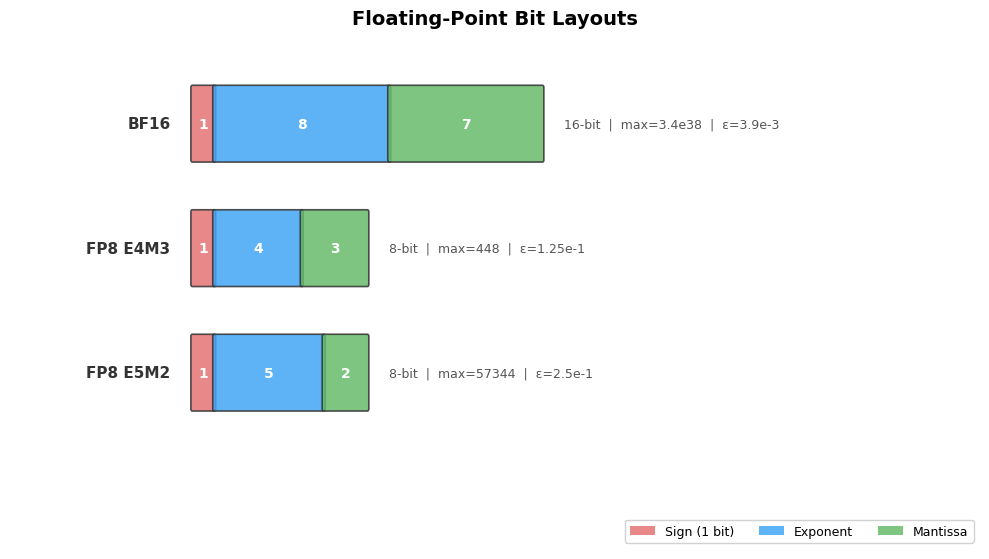

In [25]:
fig, ax = draw_float_bits(formats=["bf16", "fp8_e4m3", "fp8_e5m2"])
plt.show()

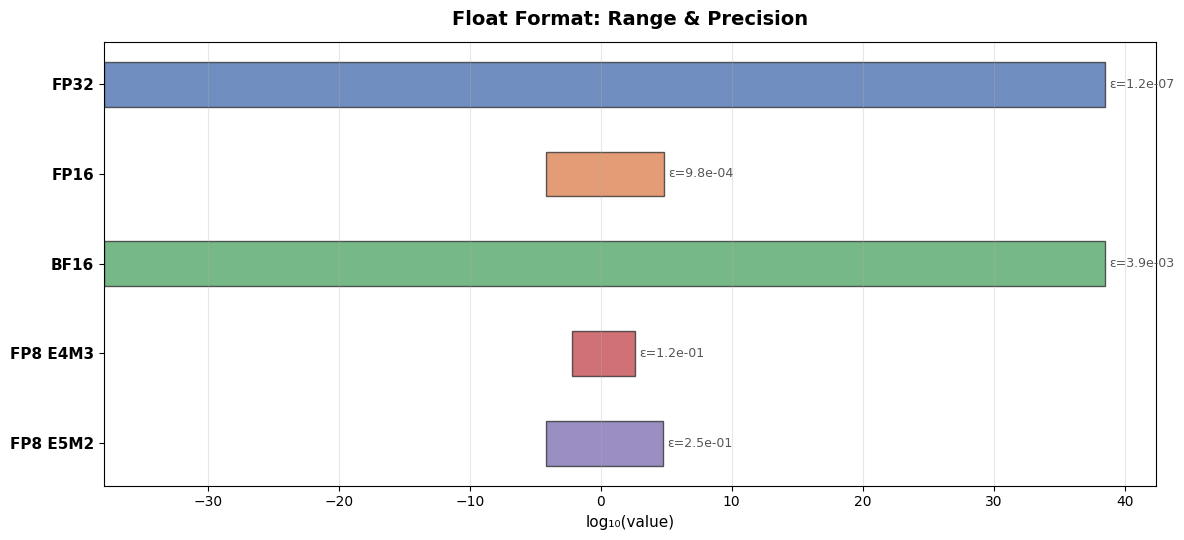

In [26]:
fig, ax = draw_precision_comparison()
plt.show()

In [27]:
# Compare all formats side by side
comparison_table(
    ["Format", "Bits", "Exponent", "Mantissa", "Max", "Epsilon", "Best For"],
    [
        ["FP32", "32", "8", "23", "3.4e38", "1.2e-7", "Master weights, optimizer"],
        ["BF16", "16", "8", "7", "3.4e38", "3.9e-3", "General training compute"],
        ["FP16", "16", "5", "10", "65504", "9.8e-4", "Training (with loss scaling)"],
        ["FP8 E4M3", "8", "4", "3", "448", "0.125", "Forward activations/weights"],
        ["FP8 E5M2", "8", "5", "2", "57344", "0.25", "Backward gradients"],
    ],
    title="Floating-Point Format Comparison"
)

Format,Bits,Exponent,Mantissa,Max,Epsilon,Best For
FP32,32,8,23,3.4e38,1.2e-7,"Master weights, optimizer"
BF16,16,8,7,3.4e38,3.9e-3,General training compute
FP16,16,5,10,65504,9.8e-4,Training (with loss scaling)
FP8 E4M3,8,4,3,448,0.125,Forward activations/weights
FP8 E5M2,8,5,2,57344,0.25,Backward gradients


## 11. FP8 Vendor Landscape

Different hardware vendors implement FP8 differently:

In [28]:
comparison_table(
    ["", "NVIDIA (H100/B200)", "AMD (MI300X)", "Intel (Gaudi 2/3)"],
    [
        ["Hardware Gen", "Hopper / Blackwell", "CDNA 3", "Habana Gaudi"],
        ["FP8 Formats", "E4M3 + E5M2", "E4M3 + E5M2 (OCP standard)", "E4M3 + E5M2"],
        ["Software Stack",
         "Transformer Engine (TE)<br>+ cuDNN FP8 kernels",
         "ROCm + hipBLASLt<br>+ PyTorch native",
         "SynapseAI + Habana<br>quantization toolkit"],
        ["Scaling Approach",
         "<b>Delayed scaling</b>:<br>scale from prev iteration's amax",
         "<b>Just-in-time scaling</b>:<br>compute scale per tensor",
         "Per-tensor dynamic scaling"],
        ["Key Feature",
         "Mature ecosystem,<br>widest adoption",
         "Native FP8 in HW,<br>OCP standard compliance",
         "Integrated in Gaudi HW,<br>optimized for transformers"],
        ["Framework Support",
         "PyTorch, JAX, TF<br>(via Transformer Engine)",
         "PyTorch (torch.float8)<br>ROCm native",
         "PyTorch (via Habana plugin)"],
    ],
    title="FP8 Hardware Vendor Comparison"
)

,NVIDIA (H100/B200),AMD (MI300X),Intel (Gaudi 2/3)
Hardware Gen,Hopper / Blackwell,CDNA 3,Habana Gaudi
FP8 Formats,E4M3 + E5M2,E4M3 + E5M2 (OCP standard),E4M3 + E5M2
Software Stack,Transformer Engine (TE)+ cuDNN FP8 kernels,ROCm + hipBLASLt+ PyTorch native,SynapseAI + Habanaquantization toolkit
Scaling Approach,Delayed scaling:scale from prev iteration's amax,Just-in-time scaling:compute scale per tensor,Per-tensor dynamic scaling
Key Feature,"Mature ecosystem,widest adoption","Native FP8 in HW,OCP standard compliance","Integrated in Gaudi HW,optimized for transformers"
Framework Support,"PyTorch, JAX, TF(via Transformer Engine)",PyTorch (torch.float8)ROCm native,PyTorch (via Habana plugin)


In [29]:
info_box(
    "<b>OCP (Open Compute Project) FP8</b> — An industry standard for FP8 formats, "
    "ensuring E4M3 and E5M2 have the same bit-level semantics across vendors. NVIDIA, AMD, "
    "Intel, Arm, and Qualcomm all participate in this standard.<br><br>"
    "<b>Delayed Scaling (NVIDIA)</b> — Instead of computing the scaling factor by scanning "
    "the tensor (extra memory pass), use the maximum absolute value (amax) from the <i>previous</i> "
    "iteration. This avoids overhead but requires an amax history buffer.",
    title="Key Concepts"
)

## 12. FP8 Quantize/Dequantize in PyTorch

PyTorch (2.1+) natively supports FP8 dtypes: `torch.float8_e4m3fn` and `torch.float8_e5m2`.
Let's see how to use them:

In [30]:
# Check FP8 dtype availability
try:
    e4m3 = torch.float8_e4m3fn
    e5m2 = torch.float8_e5m2
    print(f"FP8 E4M3: {e4m3}")
    print(f"FP8 E5M2: {e5m2}")
    FP8_AVAILABLE = True
except AttributeError:
    print("FP8 dtypes not available in this PyTorch version (need 2.1+)")
    print(f"Current PyTorch version: {torch.__version__}")
    FP8_AVAILABLE = False

FP8 E4M3: torch.float8_e4m3fn
FP8 E5M2: torch.float8_e5m2


In [31]:
# Basic FP8 casting and round-trip error
if FP8_AVAILABLE:
    torch.manual_seed(42)
    original = torch.randn(8, dtype=torch.float32)

    # Direct cast (no scaling) — values may overflow/underflow!
    fp8_e4m3 = original.to(torch.float8_e4m3fn)
    fp8_e5m2 = original.to(torch.float8_e5m2)

    # Round-trip: cast to FP8 and back to FP32
    recovered_e4m3 = fp8_e4m3.float()
    recovered_e5m2 = fp8_e5m2.float()

    print(f"{'Original':>10}  {'E4M3':>8}  {'E5M2':>8}  {'E4M3 err':>10}  {'E5M2 err':>10}")
    print("-" * 50)
    for i in range(len(original)):
        o = original[i].item()
        r4 = recovered_e4m3[i].item()
        r5 = recovered_e5m2[i].item()
        print(f"{o:>10.4f}  {r4:>8.4f}  {r5:>8.4f}  {abs(o-r4):>10.6f}  {abs(o-r5):>10.6f}")

    print(f"\nE4M3 MSE: {((original - recovered_e4m3)**2).mean().item():.6f}")
    print(f"E5M2 MSE: {((original - recovered_e5m2)**2).mean().item():.6f}")
    print("E4M3 has LOWER error (more mantissa bits = better precision)")
else:
    print("Skipping FP8 demo (PyTorch 2.1+ required)")

  Original      E4M3      E5M2    E4M3 err    E5M2 err
--------------------------------------------------
    0.3367    0.3438    0.3125    0.007060    0.024190
    0.1288    0.1250    0.1250    0.003809    0.003809
    0.2345    0.2344    0.2500    0.000087    0.015538
    0.2303    0.2344    0.2188    0.004042    0.011583
   -1.1229   -1.1250   -1.0000    0.002144    0.122856
   -0.1863   -0.1875   -0.1875    0.001172    0.001172
    2.2082    2.2500    2.0000    0.041799    0.208201
   -0.6380   -0.6250   -0.6250    0.012997    0.012997

E4M3 MSE: 0.000250
E5M2 MSE: 0.007448
E4M3 has LOWER error (more mantissa bits = better precision)


### Scaling Factors: The Key to FP8 Quality

In [32]:
# FP8 has tiny range — we MUST scale tensors to fit
if FP8_AVAILABLE:
    torch.manual_seed(42)
    # Simulate a weight tensor with values in typical range
    weights = torch.randn(4, 4) * 0.1

    # E4M3 max is 448 — compute optimal scale
    amax = weights.abs().max()
    fp8_max = torch.finfo(torch.float8_e4m3fn).max
    scale = fp8_max / amax  # scale so max value maps to fp8 max

    # Quantize with scaling
    scaled_weights = weights * scale
    fp8_weights = scaled_weights.to(torch.float8_e4m3fn)

    # Dequantize
    recovered = fp8_weights.float() / scale

    error_no_scale = ((weights - weights.to(torch.float8_e4m3fn).float())**2).mean()
    error_with_scale = ((weights - recovered)**2).mean()

    print(f"Scale factor: {scale.item():.1f}  (amax={amax.item():.4f}, fp8_max={fp8_max})")
    print(f"MSE without scaling: {error_no_scale.item():.8f}")
    print(f"MSE with scaling:    {error_with_scale.item():.8f}")
    print(f"Improvement:         {error_no_scale.item() / error_with_scale.item():.1f}x better")
else:
    print("Skipping (PyTorch 2.1+ required)")

Scale factor: 2127.7  (amax=0.2106, fp8_max=448.0)
MSE without scaling: 0.00001557
MSE with scaling:    0.00000521
Improvement:         3.0x better


In [33]:
# Per-tensor vs per-channel quantization
if FP8_AVAILABLE:
    torch.manual_seed(42)
    # Weight matrix where different rows have very different magnitudes
    W = torch.cat([
        torch.randn(2, 8) * 0.01,   # small rows
        torch.randn(2, 8) * 10.0,   # large rows
    ])

    # Per-tensor: one scale for entire matrix
    amax_tensor = W.abs().max()
    scale_tensor = torch.finfo(torch.float8_e4m3fn).max / amax_tensor
    fp8_tensor = (W * scale_tensor).to(torch.float8_e4m3fn)
    recovered_tensor = fp8_tensor.float() / scale_tensor
    mse_tensor = ((W - recovered_tensor)**2).mean()

    # Per-channel (per-row): one scale per row
    amax_channel = W.abs().amax(dim=1, keepdim=True)
    scale_channel = torch.finfo(torch.float8_e4m3fn).max / amax_channel
    fp8_channel = (W * scale_channel).to(torch.float8_e4m3fn)
    recovered_channel = fp8_channel.float() / scale_channel
    mse_channel = ((W - recovered_channel)**2).mean()

    print(f"Weight matrix shape: {W.shape}")
    print(f"Row magnitudes: {W.abs().amax(dim=1).tolist()}")
    print(f"\nPer-tensor MSE:  {mse_tensor.item():.8f}")
    print(f"Per-channel MSE: {mse_channel.item():.8f}")
    print(f"Per-channel is {mse_tensor.item() / mse_channel.item():.1f}x better!")
    print("\nPer-channel handles mixed magnitudes much better.")
else:
    print("Skipping (PyTorch 2.1+ required)")

Weight matrix shape: torch.Size([4, 8])
Row magnitudes: [0.021055208519101143, 0.016487229615449905, 16.80620574951172, 13.34737777709961]

Per-tensor MSE:  0.01867692
Per-channel MSE: 0.01910548
Per-channel is 1.0x better!

Per-channel handles mixed magnitudes much better.


## 13. FP8 Training Recipe

The full FP8 training recipe assigns different formats to different stages:

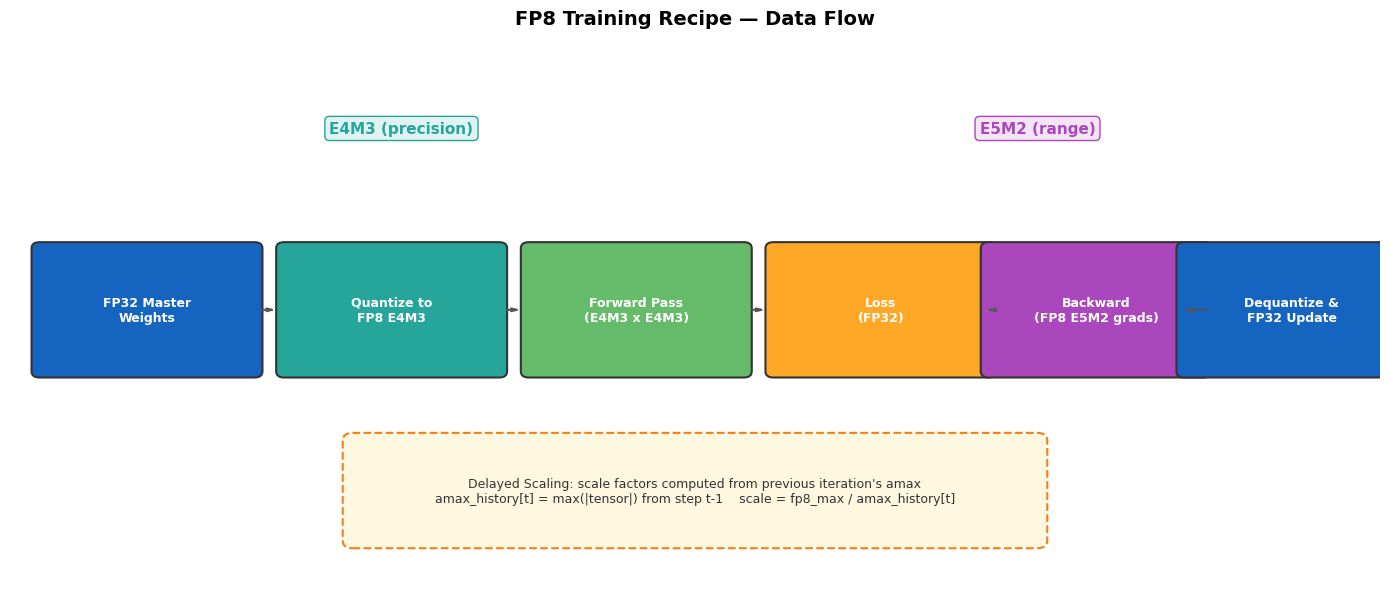

In [34]:
# FP8 training data flow
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")
ax.set_title("FP8 Training Recipe — Data Flow", fontsize=14, fontweight="bold", pad=12)

# Stages
boxes = [
    (0.3,  3.5, "FP32 Master\nWeights",    "#1565C0"),
    (2.8,  3.5, "Quantize to\nFP8 E4M3",   "#26A69A"),
    (5.3,  3.5, "Forward Pass\n(E4M3 x E4M3)", "#66BB6A"),
    (7.8,  3.5, "Loss\n(FP32)",             "#FFA726"),
    (10.0, 3.5, "Backward\n(FP8 E5M2 grads)", "#AB47BC"),
    (12.0, 3.5, "Dequantize &\nFP32 Update", "#1565C0"),
]

for i, (x, y, label, color) in enumerate(boxes):
    w, h = 2.2, 1.6
    ax.add_patch(patches.FancyBboxPatch((x, y - h/2), w, h,
        boxstyle="round,pad=0.08", facecolor=color, edgecolor="#333", lw=1.5))
    ax.text(x + w/2, y, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")
    if i < len(boxes) - 1:
        nx = boxes[i+1][0]
        ax.annotate("", xy=(nx - 0.05, y), xytext=(x + w + 0.05, y),
            arrowprops=dict(arrowstyle="->,head_width=0.1", color="#555", lw=1.5))

# Format labels
ax.text(4.0, 5.8, "E4M3 (precision)", ha="center",
        fontsize=11, fontweight="bold", color="#26A69A",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#E0F2F1", edgecolor="#26A69A"))
ax.text(10.5, 5.8, "E5M2 (range)", ha="center",
        fontsize=11, fontweight="bold", color="#AB47BC",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#F3E5F5", edgecolor="#AB47BC"))

# Delayed scaling annotation
ax.add_patch(patches.FancyBboxPatch((3.5, 0.5), 7, 1.3,
    boxstyle="round,pad=0.1", facecolor="#FFF8E1", edgecolor="#F57F17", lw=1.5, ls="--"))
ax.text(7, 1.15, "Delayed Scaling: scale factors computed from previous iteration's amax\n"
        "amax_history[t] = max(|tensor|) from step t-1    scale = fp8_max / amax_history[t]",
        ha="center", va="center", fontsize=9, color="#333")

plt.tight_layout()
plt.show()

In [35]:
info_box(
    "<b>Delayed Scaling</b> — Computing the optimal scale factor requires scanning the entire "
    "tensor to find the maximum absolute value (amax). This extra pass costs time. Delayed "
    "scaling avoids this by using the amax from the <i>previous</i> training step. In practice, "
    "tensor statistics change slowly between steps, so the previous amax is a good approximation."
    "<br><br>"
    "<b>Amax History</b> — NVIDIA's Transformer Engine keeps a rolling window of amax values "
    "(e.g., last 1024 steps) and uses the maximum of this window as the scale factor. This "
    "handles occasional spikes gracefully.",
    title="Delayed Scaling & Amax History"
)

In [36]:
# Memory savings: BF16 vs FP8
comparison_table(
    ["", "BF16 Mixed Precision", "FP8 Mixed Precision", "Savings (FP8 vs BF16)"],
    [
        ["Activation memory", "2 bytes/element", "1 byte/element", "<b>2x smaller</b>"],
        ["Weight (compute copy)", "2 bytes/param", "1 byte/param", "2x smaller"],
        ["Communication (TP)", "2 bytes/element", "1 byte/element", "2x smaller"],
        ["Master weights", "4 bytes/param (FP32)", "4 bytes/param (FP32)", "Same"],
        ["Optimizer states", "8 bytes/param (FP32)", "8 bytes/param (FP32)", "Same"],
        ["Tensor core speed", "~2x vs FP32", "~4x vs FP32", "<b>~2x faster than BF16</b>"],
    ],
    title="BF16 vs FP8: Memory & Compute"
)

,BF16 Mixed Precision,FP8 Mixed Precision,Savings (FP8 vs BF16)
Activation memory,2 bytes/element,1 byte/element,2x smaller
Weight (compute copy),2 bytes/param,1 byte/param,2x smaller
Communication (TP),2 bytes/element,1 byte/element,2x smaller
Master weights,4 bytes/param (FP32),4 bytes/param (FP32),Same
Optimizer states,8 bytes/param (FP32),8 bytes/param (FP32),Same
Tensor core speed,~2x vs FP32,~4x vs FP32,~2x faster than BF16


---
# Part 3: Beyond FP8
---

## 14. FP4 and Microscaling (MX) Formats

The push for lower precision continues. Microsoft and industry partners propose
**Microscaling (MX)** formats that use a **shared exponent** per block of values:

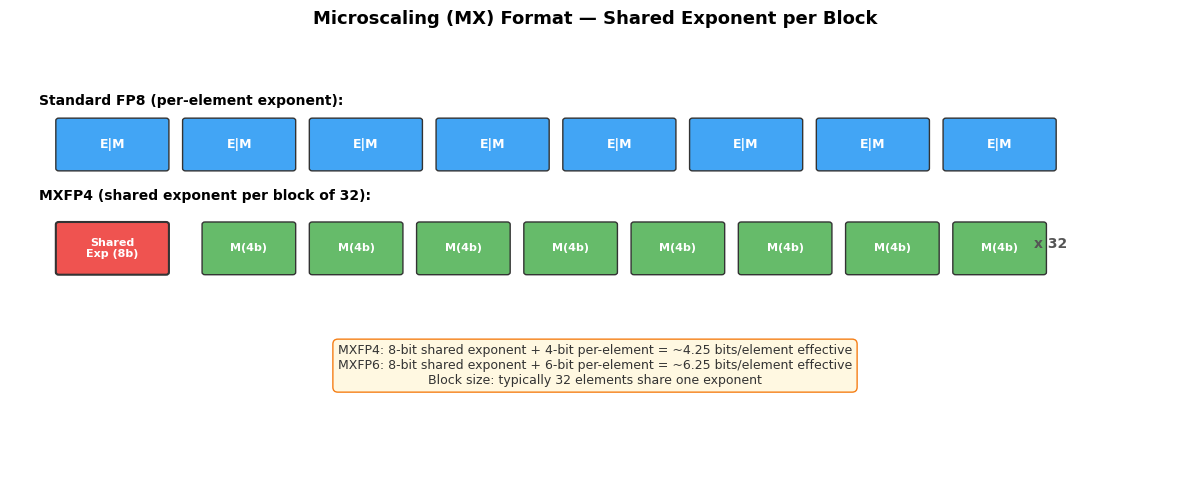

In [37]:
# Visualize MX format concept
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5.5)
ax.axis("off")
ax.set_title("Microscaling (MX) Format — Shared Exponent per Block", fontsize=13, fontweight="bold", pad=12)

# Regular FP8: each element has its own exponent
y = 4.2
ax.text(0.3, y + 0.5, "Standard FP8 (per-element exponent):", fontsize=10, fontweight="bold")
for i in range(8):
    x = 0.5 + i * 1.3
    ax.add_patch(patches.FancyBboxPatch((x, y - 0.3), 1.1, 0.6,
        boxstyle="round,pad=0.03", facecolor="#42A5F5", edgecolor="#333", lw=1))
    ax.text(x + 0.55, y, f"E|M", ha="center", va="center", fontsize=9, color="white", fontweight="bold")

# MX format: shared exponent + small per-element mantissa
y = 2.5
ax.text(0.3, y + 1.0, "MXFP4 (shared exponent per block of 32):", fontsize=10, fontweight="bold")

# Shared exponent box
ax.add_patch(patches.FancyBboxPatch((0.5, y + 0.1), 1.1, 0.6,
    boxstyle="round,pad=0.03", facecolor="#EF5350", edgecolor="#333", lw=1.5))
ax.text(1.05, y + 0.4, "Shared\nExp (8b)", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# Per-element mantissa blocks
for i in range(8):
    x = 2.0 + i * 1.1
    ax.add_patch(patches.FancyBboxPatch((x, y + 0.1), 0.9, 0.6,
        boxstyle="round,pad=0.03", facecolor="#66BB6A", edgecolor="#333", lw=1))
    ax.text(x + 0.45, y + 0.4, "M(4b)", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
ax.text(10.5, y + 0.4, "x 32", fontsize=10, fontweight="bold", color="#555")

# Annotation
ax.text(6, 1.2,
    "MXFP4: 8-bit shared exponent + 4-bit per-element = ~4.25 bits/element effective\n"
    "MXFP6: 8-bit shared exponent + 6-bit per-element = ~6.25 bits/element effective\n"
    "Block size: typically 32 elements share one exponent",
    ha="center", fontsize=9, color="#333",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF8E1", edgecolor="#F57F17"))

plt.tight_layout()
plt.show()

In [38]:
comparison_table(
    ["Format", "Bits/Element", "Approach", "Hardware Support", "Maturity"],
    [
        ["MXFP6", "~6.25", "Shared exponent (8b) + 6b per element", "NVIDIA Blackwell (B200)", "Early production"],
        ["MXFP4", "~4.25", "Shared exponent (8b) + 4b per element", "NVIDIA Blackwell (B200)", "Research/early"],
        ["NF4", "4", "Normal-float 4-bit (QLoRA)", "CPU/GPU (software)", "Production (inference)"],
        ["INT4", "4", "Uniform integer quantization", "Various (mostly inference)", "Production (inference)"],
    ],
    title="Sub-8-bit Formats"
)

Format,Bits/Element,Approach,Hardware Support,Maturity
MXFP6,~6.25,Shared exponent (8b) + 6b per element,NVIDIA Blackwell (B200),Early production
MXFP4,~4.25,Shared exponent (8b) + 4b per element,NVIDIA Blackwell (B200),Research/early
NF4,4,Normal-float 4-bit (QLoRA),CPU/GPU (software),Production (inference)
INT4,4,Uniform integer quantization,Various (mostly inference),Production (inference)


## 15. Integer and Binary Training Research

Researchers are exploring even more radical approaches:

In [39]:
comparison_table(
    ["Approach", "Key Idea", "Status", "Challenges"],
    [
        ["INT8 Training",
         "Use 8-bit integers for forward/backward. Requires careful scaling "
         "since integers have no exponent.",
         "Research (papers from 2022-2024). Some inference production use.",
         "Accumulator overflow; no hardware training support yet"],
        ["BitNet (1-bit weights)",
         "Constrain weights to {-1, +1}. Activations remain higher precision. "
         "Replaces multiplications with additions.",
         "Microsoft Research (2023-2024). BitNet b1.58 uses {-1, 0, +1}.",
         "Training stability; needs custom kernels; accuracy gap on small models"],
        ["FP4 Training",
         "4-bit floating point for forward pass. Requires very aggressive "
         "scaling and often mixed with higher precision for backward.",
         "Research (2024+). NVIDIA Blackwell has some FP4 tensor core support.",
         "Severe precision loss; limited to specific layer types"],
        ["Logarithmic Number System",
         "Represent values as fixed-point log. Multiplication becomes addition. "
         "Potentially very hardware-efficient.",
         "Academic research. No mainstream hardware support.",
         "Addition is expensive in log domain; limited adoption"],
    ],
    title="Research Frontier: Ultra-Low Precision Training"
)

Approach,Key Idea,Status,Challenges
INT8 Training,Use 8-bit integers for forward/backward. Requires careful scaling since integers have no exponent.,Research (papers from 2022-2024). Some inference production use.,Accumulator overflow; no hardware training support yet
BitNet (1-bit weights),"Constrain weights to {-1, +1}. Activations remain higher precision. Replaces multiplications with additions.","Microsoft Research (2023-2024). BitNet b1.58 uses {-1, 0, +1}.",Training stability; needs custom kernels; accuracy gap on small models
FP4 Training,4-bit floating point for forward pass. Requires very aggressive scaling and often mixed with higher precision for backward.,Research (2024+). NVIDIA Blackwell has some FP4 tensor core support.,Severe precision loss; limited to specific layer types
Logarithmic Number System,Represent values as fixed-point log. Multiplication becomes addition. Potentially very hardware-efficient.,Academic research. No mainstream hardware support.,Addition is expensive in log domain; limited adoption


In [40]:
info_box(
    "<b>BitNet b1.58</b> (Microsoft, 2024) — Uses ternary weights {-1, 0, +1}, which means "
    "every matrix multiplication becomes pure addition/subtraction. For large models (3B+), "
    "the accuracy approaches full-precision transformers while being dramatically more "
    "energy-efficient. The '1.58 bits' comes from log2(3) = 1.58.<br><br>"
    "<b>Key insight:</b> As models get larger, they become more tolerant of low precision. "
    "A 1-bit 7B model can match a full-precision 3B model — the extra parameters compensate "
    "for the precision loss.",
    title="BitNet: The 1-bit Frontier"
)

## 16. Summary

What we covered in this notebook:

In [41]:
comparison_table(
    ["Precision", "Bits", "Memory/Param", "Speed vs FP32", "Hardware", "Status"],
    [
        ["FP32", "32", "16 bytes (train)", "1x", "All GPUs", "Baseline"],
        ["BF16 Mixed", "16+32", "~18 bytes (train)", "2-3x", "Ampere+ (A100, H100)", "Industry standard"],
        ["FP16 Mixed", "16+32", "~18 bytes (train)", "2-3x", "Volta+ (V100, A100)", "Mature (needs loss scaling)"],
        ["FP8 (E4M3+E5M2)", "8+32", "~14 bytes (train)", "4-6x", "Hopper+ (H100, MI300)", "Production (2024+)"],
        ["MXFP4", "~4+32", "~13 bytes (train)", "8x+ (est.)", "Blackwell (B200)", "Early (2025+)"],
        ["BitNet (1.58-bit)", "1.58", "~12.2 bytes (train)", "TBD", "Custom/CPU", "Research"],
    ],
    title="Precision Landscape — Full Comparison"
)

Precision,Bits,Memory/Param,Speed vs FP32,Hardware,Status
FP32,32,16 bytes (train),1x,All GPUs,Baseline
BF16 Mixed,16+32,~18 bytes (train),2-3x,"Ampere+ (A100, H100)",Industry standard
FP16 Mixed,16+32,~18 bytes (train),2-3x,"Volta+ (V100, A100)",Mature (needs loss scaling)
FP8 (E4M3+E5M2),8+32,~14 bytes (train),4-6x,"Hopper+ (H100, MI300)",Production (2024+)
MXFP4,~4+32,~13 bytes (train),8x+ (est.),Blackwell (B200),Early (2025+)
BitNet (1.58-bit),1.58,~12.2 bytes (train),TBD,Custom/CPU,Research


### Key Formulas

| Formula | Meaning |
|---------|---------|
| $\text{scale} = \frac{\text{fp\_max}}{\text{amax}(X)}$ | Compute scaling factor for quantization |
| $X_{\text{fp8}} = \text{cast\_fp8}(X \cdot \text{scale})$ | Quantize: scale then cast |
| $X_{\text{recovered}} = X_{\text{fp8}} / \text{scale}$ | Dequantize: cast back then unscale |
| $\text{Memory}_{\text{mixed}} \approx 18P$ bytes | Mixed-precision Adam (P = num params) |
| $\text{Memory}_{\text{fp32}} = 16P$ bytes | FP32 Adam |
| $\text{Activation savings} = 2\times$ | BF16 activations vs FP32 |

### Next Steps

This notebook covered the *computation* side of efficient training. The parallelism
notebooks (01-07) cover the *distribution* side. Together, mixed precision + parallelism
enable training models from 7B to 1T+ parameters.

### Further Reading

- [Mixed Precision Training (Micikevicius et al., 2018)](https://arxiv.org/abs/1710.03740) — The original paper
- [FP8 Formats for Deep Learning (Micikevicius et al., 2022)](https://arxiv.org/abs/2209.05433) — FP8 standard proposal
- [FP8-LM: Training FP8 Large Language Models (Peng et al., 2023)](https://arxiv.org/abs/2310.18313)
- [BitNet b1.58 (Ma et al., 2024)](https://arxiv.org/abs/2402.17764) — 1.58-bit LLMs
- [Microscaling Data Formats (OCP, 2023)](https://www.opencompute.org/documents/ocp-microscaling-formats-mx-v1-0-spec-final-pdf) — MX format spec
- [PyTorch AMP Documentation](https://pytorch.org/docs/stable/amp.html)
- [NVIDIA Transformer Engine](https://github.com/NVIDIA/TransformerEngine)